In [1]:
import warnings
warnings.filterwarnings("ignore")

from pprint import pprint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import praw

In [2]:
user_agent = "Scraper 1.0 by /u/shreyansh0909"

In [3]:
reddit = praw.Reddit(
    client_id = "R1-7xobK1PuC-_WZVb5bxg",
    client_secret = "PzRCnj-E0SbODLBCpqUhUKg6RFCXqw",
    user_agent = user_agent,
    username = "shreyansh0909",
    password = "09shreyansh09"
)

In [4]:
print(reddit.user.me())

shreyansh0909


In [5]:
# The topic that we want to search for
topicName = "stocks"

In [6]:
# We can use hot or new or rising or top, see the examples
from datetime import datetime

subreddit = reddit.subreddit(topicName)

for submission in subreddit.hot(limit = 10):
    print(submission.title)
    print(submission.id)
    print(submission.author)
    print(datetime.utcfromtimestamp(submission.created_utc).strftime('%Y-%m-%d'))
    print(submission.score)
    print(submission.upvote_ratio)
    print(submission.url)
    print(submission.num_comments)

Rate My Portfolio - r/Stocks Quarterly Thread March 2024
1b3qoq5
AutoModerator
2024-03-01
31
0.89
https://www.reddit.com/r/stocks/comments/1b3qoq5/rate_my_portfolio_rstocks_quarterly_thread_march/
208
r/Stocks Daily Discussion Wednesday - Mar 27, 2024
1boxps1
AutoModerator
2024-03-27
7
0.77
https://www.reddit.com/r/stocks/comments/1boxps1/rstocks_daily_discussion_wednesday_mar_27_2024/
82
'Apple will prevail': US faces uphill slog in new antitrust battle
1boymg5
EchoInTheHoller
2024-03-27
125
0.87
https://www.reddit.com/r/stocks/comments/1boymg5/apple_will_prevail_us_faces_uphill_slog_in_new/
27
UBS raises Disney stock target to $140 on earnings potential. Stock opened $121
1bp28wi
Fresh-Finger-4323
2024-03-27
59
0.89
https://www.reddit.com/r/stocks/comments/1bp28wi/ubs_raises_disney_stock_target_to_140_on_earnings/
24
H&M shares jump 13% as profit smashes expectations
1bowzcw
Puginator
2024-03-27
136
0.93
https://www.reddit.com/r/stocks/comments/1bowzcw/hm_shares_jump_13_as_profit_sma

In [7]:
# We can use hot or new or rising or top
submissions = set()

posts = subreddit.hot(limit=None)

# Just add up all the headlines of the reddits into a set
for submission in posts:
    submissions.add(submission)

print(len(submissions))

218


In [8]:
headlines = []

for submission in submissions:    
    headlines.append([submission.title, submission.num_comments, submission.score, submission.upvote_ratio, datetime.utcfromtimestamp(submission.created_utc)])

In [9]:
df = pd.DataFrame(headlines)

In [10]:
df.columns = ["Title", "Number of Comments", "Score", "Upvote-Ratio", "DateTime"]

df.head()

,Title,Number of Comments,Score,Upvote-Ratio,DateTime
0,Short Sell Boeing,316,1106,0.81,2024-03-12 20:32:56
1,Is VWELX a good 'out of the market' asset?,0,5,1.00,2024-03-18 04:54:12
2,Do Russian stock holders in the west have any ...,69,0,0.49,2024-03-24 17:59:51
3,GigaCloud Tech ($GCT) reports record revenue a...,37,42,0.81,2024-03-17 15:02:13
4,The U.S. Department of Justice (DOJ) is prepar...,216,606,0.95,2024-03-21 11:32:28


In [11]:
import regex as re

# Define a function to clean the text
def clean(text):
# Removes all special characters and numericals leaving the alphabets
    text = re.sub('[^A-Za-z]+', ' ', text)
    return text

In [12]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from nltk import pos_tag
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('wordnet')
from nltk.corpus import wordnet
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\91934\anaconda3\pkgs...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91934\anaconda3\pkgs...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91934\anaconda3\pkgs...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\91934\anaconda3\pkgs...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [13]:
# Define a function to clean the text
def clean(text):
# Removes all special characters and numericals leaving the alphabets
    text = re.sub('[^A-Za-z]+', ' ', text)
    return text

In [14]:
# Cleaning the text in the review column
df['Cleaned Title'] = df['Title'].apply(clean)
df.head()

,Title,Number of Comments,Score,Upvote-Ratio,DateTime,Cleaned Title
0,Short Sell Boeing,316,1106,0.81,2024-03-12 20:32:56,Short Sell Boeing
1,Is VWELX a good 'out of the market' asset?,0,5,1.00,2024-03-18 04:54:12,Is VWELX a good out of the market asset
2,Do Russian stock holders in the west have any ...,69,0,0.49,2024-03-24 17:59:51,Do Russian stock holders in the west have any ...
3,GigaCloud Tech ($GCT) reports record revenue a...,37,42,0.81,2024-03-17 15:02:13,GigaCloud Tech GCT reports record revenue and ...
4,The U.S. Department of Justice (DOJ) is prepar...,216,606,0.95,2024-03-21 11:32:28,The U S Department of Justice DOJ is preparing...


In [15]:
# POS tagger dictionary
pos_dict = {'J':wordnet.ADJ, 'V':wordnet.VERB, 'N':wordnet.NOUN, 'R':wordnet.ADV}
def token_stop_pos(text):
    tags = pos_tag(word_tokenize(text))
    newlist = []
    for word, tag in tags:
        if word.lower() not in set(stopwords.words('english')):
            newlist.append(tuple([word, pos_dict.get(tag[0])]))
    return newlist

In [16]:
df['POS tagged'] = df['Cleaned Title'].apply(token_stop_pos)
df.head()

,Title,Number of Comments,Score,Upvote-Ratio,DateTime,Cleaned Title,POS tagged
0,Short Sell Boeing,316,1106,0.81,2024-03-12 20:32:56,Short Sell Boeing,"[(Short, n), (Sell, n), (Boeing, n)]"
1,Is VWELX a good 'out of the market' asset?,0,5,1.00,2024-03-18 04:54:12,Is VWELX a good out of the market asset,"[(VWELX, n), (good, a), (market, n), (asset, n)]"
2,Do Russian stock holders in the west have any ...,69,0,0.49,2024-03-24 17:59:51,Do Russian stock holders in the west have any ...,"[(Russian, a), (stock, n), (holders, n), (west..."
3,GigaCloud Tech ($GCT) reports record revenue a...,37,42,0.81,2024-03-17 15:02:13,GigaCloud Tech GCT reports record revenue and ...,"[(GigaCloud, n), (Tech, n), (GCT, n), (reports..."
4,The U.S. Department of Justice (DOJ) is prepar...,216,606,0.95,2024-03-21 11:32:28,The U S Department of Justice DOJ is preparing...,"[(U, n), (Department, n), (Justice, n), (DOJ, ..."


In [17]:
from nltk.stem import WordNetLemmatizer
wordnet_lemmatizer = WordNetLemmatizer()

def lemmatize(pos_data):
    lemma_rew = " "
    for word, pos in pos_data:
        if not pos:
            lemma = word
            lemma_rew = lemma_rew + " " + lemma
        else:
            lemma = wordnet_lemmatizer.lemmatize(word, pos=pos)
            lemma_rew = lemma_rew + " " + lemma
    return lemma_rew

In [18]:
df['Lemma'] = df['POS tagged'].apply(lemmatize)
df.head()

,Title,Number of Comments,Score,Upvote-Ratio,DateTime,Cleaned Title,POS tagged,Lemma
0,Short Sell Boeing,316,1106,0.81,2024-03-12 20:32:56,Short Sell Boeing,"[(Short, n), (Sell, n), (Boeing, n)]",Short Sell Boeing
1,Is VWELX a good 'out of the market' asset?,0,5,1.00,2024-03-18 04:54:12,Is VWELX a good out of the market asset,"[(VWELX, n), (good, a), (market, n), (asset, n)]",VWELX good market asset
2,Do Russian stock holders in the west have any ...,69,0,0.49,2024-03-24 17:59:51,Do Russian stock holders in the west have any ...,"[(Russian, a), (stock, n), (holders, n), (west...",Russian stock holder west chance recovery
3,GigaCloud Tech ($GCT) reports record revenue a...,37,42,0.81,2024-03-17 15:02:13,GigaCloud Tech GCT reports record revenue and ...,"[(GigaCloud, n), (Tech, n), (GCT, n), (reports...",GigaCloud Tech GCT report record revenue pro...
4,The U.S. Department of Justice (DOJ) is prepar...,216,606,0.95,2024-03-21 11:32:28,The U S Department of Justice DOJ is preparing...,"[(U, n), (Department, n), (Justice, n), (DOJ, ...",U Department Justice DOJ prepare sue Apple A...


In [19]:
from textblob import TextBlob
# function to calculate subjectivity
def getSubjectivity(review):
    return TextBlob(review).sentiment.subjectivity
    
# function to calculate polarity
def getPolarity(review):
    return TextBlob(review).sentiment.polarity

In [20]:
# function to analyze the reviews
def analysis(score):
    if score < 0:
        return 'Negative'
    elif score == 0:
        return 'Neutral'
    else:
        return 'Positive'

In [21]:
df['Subjectivity'] = df['Lemma'].apply(getSubjectivity) 
df['Polarity'] = df['Lemma'].apply(getPolarity) 
df['Analysis'] = df['Polarity'].apply(analysis)
df.head()

,Title,Number of Comments,Score,Upvote-Ratio,DateTime,Cleaned Title,POS tagged,Lemma,Subjectivity,Polarity,Analysis
0,Short Sell Boeing,316,1106,0.81,2024-03-12 20:32:56,Short Sell Boeing,"[(Short, n), (Sell, n), (Boeing, n)]",Short Sell Boeing,0.3,0.0,Neutral
1,Is VWELX a good 'out of the market' asset?,0,5,1.00,2024-03-18 04:54:12,Is VWELX a good out of the market asset,"[(VWELX, n), (good, a), (market, n), (asset, n)]",VWELX good market asset,0.6,0.7,Positive
2,Do Russian stock holders in the west have any ...,69,0,0.49,2024-03-24 17:59:51,Do Russian stock holders in the west have any ...,"[(Russian, a), (stock, n), (holders, n), (west...",Russian stock holder west chance recovery,0.0,0.0,Neutral
3,GigaCloud Tech ($GCT) reports record revenue a...,37,42,0.81,2024-03-17 15:02:13,GigaCloud Tech GCT reports record revenue and ...,"[(GigaCloud, n), (Tech, n), (GCT, n), (reports...",GigaCloud Tech GCT report record revenue pro...,0.0,0.0,Neutral
4,The U.S. Department of Justice (DOJ) is prepar...,216,606,0.95,2024-03-21 11:32:28,The U S Department of Justice DOJ is preparing...,"[(U, n), (Department, n), (Justice, n), (DOJ, ...",U Department Justice DOJ prepare sue Apple A...,0.1,-0.1,Negative


In [22]:
tb_counts = df.Analysis.value_counts()

tb_counts

Neutral     153
Positive     36
Negative     29
Name: Analysis, dtype: int64

In [23]:
# Since the first row is a clear outlier, lets remove it, also, we can work on a better algorithm to remove outliers

# Calculate the time differences between consecutive datetime values
df['Time_Diff'] = df['DateTime'].diff().dt.total_seconds().fillna(0)

# Calculate Z-score for the time differences
threshold = 2  # Set your threshold value for Z-score, e.g., 2 or 3
df['Time_Diff_Zscore'] = np.abs((df['Time_Diff'] - df['Time_Diff'].mean()) / df['Time_Diff'].std())

# Remove rows with time differences considered as outliers
df_cleaned = df[df['Time_Diff_Zscore'] <= threshold]

# Drop the intermediate columns if not needed
df_cleaned = df_cleaned.drop(['Time_Diff', 'Time_Diff_Zscore'], axis=1)

df_cleaned

,Title,Number of Comments,Score,Upvote-Ratio,DateTime,Cleaned Title,POS tagged,Lemma,Subjectivity,Polarity,Analysis
0,Short Sell Boeing,316,1106,0.81,2024-03-12 20:32:56,Short Sell Boeing,"[(Short, n), (Sell, n), (Boeing, n)]",Short Sell Boeing,0.3,0.0,Neutral
1,Is VWELX a good 'out of the market' asset?,0,5,1.00,2024-03-18 04:54:12,Is VWELX a good out of the market asset,"[(VWELX, n), (good, a), (market, n), (asset, n)]",VWELX good market asset,0.6,0.7,Positive
2,Do Russian stock holders in the west have any ...,69,0,0.49,2024-03-24 17:59:51,Do Russian stock holders in the west have any ...,"[(Russian, a), (stock, n), (holders, n), (west...",Russian stock holder west chance recovery,0.0,0.0,Neutral
3,GigaCloud Tech ($GCT) reports record revenue a...,37,42,0.81,2024-03-17 15:02:13,GigaCloud Tech GCT reports record revenue and ...,"[(GigaCloud, n), (Tech, n), (GCT, n), (reports...",GigaCloud Tech GCT report record revenue pro...,0.0,0.0,Neutral
4,The U.S. Department of Justice (DOJ) is prepar...,216,606,0.95,2024-03-21 11:32:28,The U S Department of Justice DOJ is preparing...,"[(U, n), (Department, n), (Justice, n), (DOJ, ...",U Department Justice DOJ prepare sue Apple A...,0.1,-0.1,Negative
...,...,...,...,...,...,...,...,...,...,...,...
213,"Disney Proxy: Glass-Lewis, heirs, George Lucas...",1,3,0.57,2024-03-22 15:54:46,Disney Proxy Glass Lewis heirs George Lucas La...,"[(Disney, n), (Proxy, n), (Glass, n), (Lewis, ...",Disney Proxy Glass Lewis heirs George Lucas ...,0.0,0.0,Neutral
214,Does anyone ever vote with their shares?,48,44,0.80,2024-03-17 16:24:41,Does anyone ever vote with their shares,"[(anyone, n), (ever, r), (vote, n), (shares, n)]",anyone ever vote share,0.0,0.0,Neutral
215,Anyone have Astera Labs' IPO on their radar? I...,21,24,0.90,2024-03-19 16:17:01,Anyone have Astera Labs IPO on their radar If ...,"[(Anyone, n), (Astera, n), (Labs, n), (IPO, n)...",Anyone Astera Labs IPO radar thought,0.0,0.0,Neutral
216,Nike beats holiday revenue estimates — but its...,39,188,0.91,2024-03-21 22:07:46,Nike beats holiday revenue estimates but its C...,"[(Nike, n), (beats, n), (holiday, v), (revenue...",Nike beat holiday revenue estimate China sal...,0.4,-0.3,Negative


In [24]:
df = df_cleaned.sort_values('DateTime')

df

,Title,Number of Comments,Score,Upvote-Ratio,DateTime,Cleaned Title,POS tagged,Lemma,Subjectivity,Polarity,Analysis
0,Short Sell Boeing,316,1106,0.81,2024-03-12 20:32:56,Short Sell Boeing,"[(Short, n), (Sell, n), (Boeing, n)]",Short Sell Boeing,0.30,0.0,Neutral
170,Why Warren Buffett is not selling AAPL (anymor...,49,63,0.74,2024-03-13 11:53:20,Why Warren Buffett is not selling AAPL anymore...,"[(Warren, n), (Buffett, n), (selling, v), (AAP...",Warren Buffett sell AAPL anymore risk AAPL,0.00,0.0,Neutral
103,Pentagon Scraps $2.5B Grant to Intel,109,436,0.88,2024-03-13 12:56:14,Pentagon Scraps B Grant to Intel,"[(Pentagon, n), (Scraps, n), (B, n), (Grant, n...",Pentagon Scraps B Grant Intel,0.00,0.0,Neutral
60,Tiktok Ban in US and META SNAP,280,345,0.91,2024-03-13 16:32:00,Tiktok Ban in US and META SNAP,"[(Tiktok, n), (Ban, n), (US, n), (META, n), (S...",Tiktok Ban US META SNAP,0.00,0.0,Neutral
160,If you were down 5 figures on a stock but you'...,630,345,0.80,2024-03-13 18:47:04,If you were down figures on a stock but you d ...,"[(figures, n), (stock, n), (buy, v), (current,...",figure stock buy current price would double ...,0.20,0.0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...
29,H&M shares jump 13% as profit smashes expectat...,21,133,0.93,2024-03-27 08:35:13,H M shares jump as profit smashes expectations,"[(H, n), (shares, n), (jump, n), (profit, n), ...",H share jump profit smash expectation,0.00,0.0,Neutral
46,"r/Stocks Daily Discussion Wednesday - Mar 27, ...",82,7,0.77,2024-03-27 09:30:07,r Stocks Daily Discussion Wednesday Mar,"[(r, n), (Stocks, n), (Daily, n), (Discussion,...",r Stocks Daily Discussion Wednesday Mar,0.00,0.0,Neutral
98,Anyone know what Motley Fool's ten recommended...,25,0,0.22,2024-03-27 13:10:25,Anyone know what Motley Fool s ten recommended...,"[(Anyone, n), (know, v), (Motley, n), (Fool, n...",Anyone know Motley Fool ten recommended stock,0.45,0.3,Positive
155,These are the stocks on my watchlist (3/27),0,0,0.25,2024-03-27 14:00:06,These are the stocks on my watchlist,"[(stocks, n), (watchlist, n)]",stock watchlist,0.00,0.0,Neutral


In [25]:
startDateOfPosts = min(df["DateTime"])
endDateOfPosts = max(df["DateTime"])

In [26]:
import yfinance as yf

#define the ticker symbol
tickerSymbol = 'DJIA'

#get data on this ticker
tickerData = yf.Ticker(tickerSymbol)

#get the historical prices for this ticker
tickerDf = tickerData.history(start = startDateOfPosts, end = endDateOfPosts)

#see your data
tickerDf

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-03-13 00:00:00-04:00,22.549071,22.618728,22.489365,22.539120,25900,0.00,0.0,0.0
2024-03-14 00:00:00-04:00,22.539119,22.578924,22.519217,22.542105,8800,0.00,0.0,0.0
2024-03-15 00:00:00-04:00,22.479414,22.588876,22.290344,22.360001,52500,0.00,0.0,0.0
2024-03-18 00:00:00-04:00,22.450001,22.559999,22.379999,22.420000,26400,0.11,0.0,0.0
2024-03-19 00:00:00-04:00,22.410000,22.600000,22.410000,22.530001,27700,0.00,0.0,0.0
2024-03-20 00:00:00-04:00,22.520000,22.639999,22.469999,22.635000,24700,0.00,0.0,0.0
2024-03-21 00:00:00-04:00,22.680000,22.709999,22.629999,22.709999,13400,0.00,0.0,0.0
2024-03-22 00:00:00-04:00,22.990000,22.990000,22.629999,22.700001,44600,0.00,0.0,0.0
2024-03-25 00:00:00-04:00,22.809999,22.809999,22.629999,22.809999,12200,0.00,0.0,0.0


In [27]:
# Purpose is to first change the closing prices wrt previous, i.e., up or down

In [28]:
# Calculate the difference between consecutive closing prices
tickerDf['Price_Diff'] = tickerDf['Close'].diff()

# Map the difference to indicate increase, decrease, or no change
tickerDf['Price_Change'] = tickerDf['Price_Diff'].apply(lambda x: 2 if x > 0 else (0 if x < 0 else 1))

# Drop the 'Price_Diff' column if not needed
tickerDf.drop('Price_Diff', axis=1, inplace=True)

In [29]:
# Removing first row as we're basically just differencing the consecutive column values and the first row doesn't have any predescessor
tickerDf = tickerDf.iloc[1:]

In [30]:
tickerDf

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Price_Change
Date,,,,,,,,,
2024-03-14 00:00:00-04:00,22.539119,22.578924,22.519217,22.542105,8800,0.00,0.0,0.0,2
2024-03-15 00:00:00-04:00,22.479414,22.588876,22.290344,22.360001,52500,0.00,0.0,0.0,0
2024-03-18 00:00:00-04:00,22.450001,22.559999,22.379999,22.420000,26400,0.11,0.0,0.0,2
2024-03-19 00:00:00-04:00,22.410000,22.600000,22.410000,22.530001,27700,0.00,0.0,0.0,2
2024-03-20 00:00:00-04:00,22.520000,22.639999,22.469999,22.635000,24700,0.00,0.0,0.0,2
2024-03-21 00:00:00-04:00,22.680000,22.709999,22.629999,22.709999,13400,0.00,0.0,0.0,2
2024-03-22 00:00:00-04:00,22.990000,22.990000,22.629999,22.700001,44600,0.00,0.0,0.0,0
2024-03-25 00:00:00-04:00,22.809999,22.809999,22.629999,22.809999,12200,0.00,0.0,0.0,2
2024-03-26 00:00:00-04:00,22.780001,22.780001,22.570000,22.580000,102300,0.00,0.0,0.0,0


In [31]:
df.rename(columns={'Number of Comments': 'NumberofComments'}, inplace=True)

In [32]:
# Assuming 'posts_data' is your DataFrame with columns: 'polarity', 'NumberOfComments', 'Subjectivity', 'Score', 'Lemma'
# Assuming 'start_points' contains the indices of start points

start_points = tickerDf.index.tz_localize(None)

# Create an empty DataFrame to store the accumulated data
columns_to_accumulate = ['Polarity', 'NumberofComments', 'Subjectivity', 'Score']
accumulated_df = pd.DataFrame(columns=columns_to_accumulate)
accumulated_data = {}  


# Loop through start points
for start_point in start_points:
    
    # Redefine the dictionary for each start point
    for col in columns_to_accumulate:
        accumulated_data[col] = 0
    
    # Accumulate columns until reaching the start point
    for index, row in df.iterrows():
        if row['DateTime'] >= start_point:
            break
        
        # Accumulate each column
        for col in columns_to_accumulate:
            accumulated_data[col] += row[col]
    
    # Create a new row in the accumulated DataFrame with the accumulated data
    new_row = pd.DataFrame([accumulated_data])
    accumulated_df = pd.concat([accumulated_df, new_row], ignore_index = True)

    # Reset accumulated_data to zero for the next iteration
    # accumulated_data = {col: 0 if col != 'Lemma' else '' for col in columns_to_accumulate}

# Display the accumulated DataFrame
print(accumulated_df)

   Polarity NumberofComments Subjectivity  Score
0      0.15             1883         1.65   3172
1       0.4             3543          2.5   6411
2  0.679167             6523     8.195833  11395
3  2.065152             8299    11.729672  14740
4  1.440152             9478    15.071338  17662
5  2.476515            10745    18.563384  20038
6  1.439015            13590    22.075884  26922
7  1.809848            16621    27.338384  31140
8  2.415909            17682    29.080808  34617
9  1.909091            19448    32.433081  38329


In [33]:
columns_to_diff = ['Polarity', 'NumberofComments', 'Subjectivity', 'Score']

# Calculate differences but retain the first row unchanged
posts_data_diff = accumulated_df[columns_to_diff].diff()
posts_data_diff.iloc[0] = accumulated_df.iloc[0][columns_to_diff]

In [34]:
print(posts_data_diff)

   Polarity NumberofComments Subjectivity Score
0      0.15             1883         1.65  3172
1      0.25             1660         0.85  3239
2  0.279167             2980     5.695833  4984
3  1.385985             1776     3.533838  3345
4    -0.625             1179     3.341667  2922
5  1.036364             1267     3.492045  2376
6   -1.0375             2845       3.5125  6884
7  0.370833             3031       5.2625  4218
8  0.606061             1061     1.742424  3477
9 -0.506818             1766     3.352273  3712


In [35]:
# Split the data into features and target variable
X = posts_data_diff[["NumberofComments", "Score", "Polarity", "Subjectivity"]]
Y = tickerDf["Price_Change"]

In [36]:
X

,NumberofComments,Score,Polarity,Subjectivity
0,1883,3172,0.15,1.65
1,1660,3239,0.25,0.85
2,2980,4984,0.279167,5.695833
3,1776,3345,1.385985,3.533838
4,1179,2922,-0.625,3.341667
5,1267,2376,1.036364,3.492045
6,2845,6884,-1.0375,3.5125
7,3031,4218,0.370833,5.2625
8,1061,3477,0.606061,1.742424
9,1766,3712,-0.506818,3.352273


In [37]:
Y

Date
2024-03-14 00:00:00-04:00    2
2024-03-15 00:00:00-04:00    0
2024-03-18 00:00:00-04:00    2
2024-03-19 00:00:00-04:00    2
2024-03-20 00:00:00-04:00    2
2024-03-21 00:00:00-04:00    2
2024-03-22 00:00:00-04:00    0
2024-03-25 00:00:00-04:00    2
2024-03-26 00:00:00-04:00    0
2024-03-27 00:00:00-04:00    2
Name: Price_Change, dtype: int64

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [39]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [40]:
X_train = np.asarray(X_train).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)
X_test = np.asarray(X_test).astype(np.float32)
y_test = np.asarray(y_test).astype(np.float32)

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the neural network architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(len(X.columns),)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')  # Using softmax for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model using training data
history = model.fit(X_train, y_train, epochs=100, batch_size=10, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy}")

Epoch 1/100
1/1 [==============================] - 2s 2s/step - loss: 752.8815 - accuracy: 0.0000e+00 - val_loss: 155.4104 - val_accuracy: 0.5000
Epoch 2/100
1/1 [==============================] - 0s 40ms/step - loss: 188.4418 - accuracy: 0.3333 - val_loss: 82.4106 - val_accuracy: 0.5000
Epoch 3/100
1/1 [==============================] - 0s 41ms/step - loss: 581.1247 - accuracy: 0.1667 - val_loss: 8.1535 - val_accuracy: 0.5000
Epoch 4/100
1/1 [==============================] - 0s 41ms/step - loss: 24.6058 - accuracy: 0.8333 - val_loss: 132.6991 - val_accuracy: 0.5000
Epoch 5/100
1/1 [==============================] - 0s 46ms/step - loss: 105.5281 - accuracy: 0.6667 - val_loss: 271.8488 - val_accuracy: 0.5000
Epoch 6/100
1/1 [==============================] - 0s 46ms/step - loss: 199.5554 - accuracy: 0.5000 - val_loss: 413.6088 - val_accuracy: 0.5000
Epoch 7/100
1/1 [==============================] - 0s 55ms/step - loss: 6.8397 - accuracy: 0.8333 - val_loss: 547.2898 - val_accuracy: 0.5

In [42]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Get predictions for the test set
predictions = np.argmax(model.predict(X_test), axis=-1)

# Calculate F1 score
f1 = f1_score(y_test, predictions, average='weighted')
print(f"Test F1 Score: {f1}")

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

1/1 [==============================] - 0s 135ms/step
Test F1 Score: 0.0
Confusion Matrix:
[[0 2]
 [0 0]]


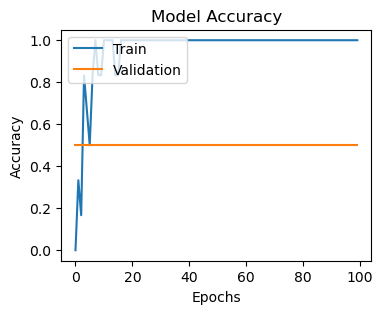

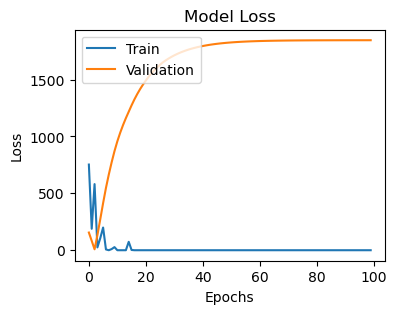

In [43]:
# Plot training & validation accuracy values
plt.figure(figsize=(4, 3))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(4, 3))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

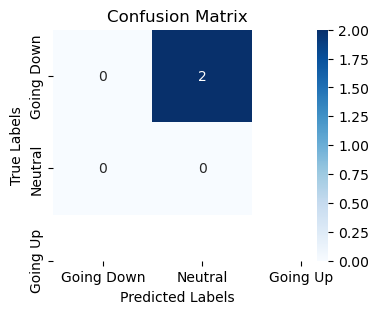

In [45]:
# Define class labels
class_labels = ['Going Down', 'Neutral', 'Going Up']  # Replace with your class labels

# Get the confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)

# Create a heatmap for the confusion matrix with specified class labels
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()